In [6]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from pathlib import Path
import re
import xml.etree.ElementTree as ET
from functools import reduce
import openpyxl
from scipy.optimize import minimize_scalar
import numpy as np
import glob
import datetime as dt
from semopy import Model
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, ccf, grangercausalitytests, zivot_andrews
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, breaks_cusumolsresid
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.api import VAR
from statsmodels.tools.tools import add_constant
from statsmodels.formula.api import ols
from statsmodels.tsa.stattools import coint
from scipy.stats import shapiro

from semopy import Model
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from arch.unitroot import PhillipsPerron
from pmdarima.arima.utils import nsdiffs

pd.set_option('display.max_columns', None)

pd.set_option('display.max_columns', None)

In [ ]:
STATGOV_BASE = "https://stat.gov.ua/sdmx/workspaces/default:integration/registry/sdmx/3.0"

def fetch_energy_series(key):
    url = f"{STATGOV_BASE}/data/dataflow/SSSU/DF_SUPPLY_USE_ENERGY/~/{key}"
    params = {
        "dimensionAtObservation": "TIME_PERIOD"
    }
    headers = {
        "Accept": "application/vnd.sdmx.data+json;version=2.0.0",
        "User-Agent": "Mozilla/5.0"
    }

    r = requests.get(url, params=params, headers=headers, timeout=60)
    # print(r.url)
    # print(r.status_code)
    r.raise_for_status()
    return r.json()

def parse_single_series_sdmx(data):
    time_dim = next(
        d for d in data["data"]["structures"][0]["dimensions"]["observation"]
        if d["id"] == "TIME_PERIOD"
    )
    time_values = [v["value"] for v in time_dim["values"]]

    dataset = data["data"]["dataSets"][0]

    if "observations" in dataset:
        obs = dataset["observations"]
    else:
        series = dataset["series"]
        first_series = next(iter(series.values()))
        obs = first_series["observations"]

    rows = []
    for obs_idx, obs_val in obs.items():
        rows.append({
            "year": time_values[int(obs_idx.split(":")[-1]) if ":" in obs_idx else int(obs_idx)],
            "value": pd.to_numeric(obs_val[0], errors="coerce")
        })

    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def build_conversion_matrix(n_years: int, s: int = 4, agg: str = "sum") -> np.ndarray:
    C = np.zeros((n_years, n_years * s))

    for i in range(n_years):
        if agg == "sum":
            C[i, i * s:(i + 1) * s] = 1.0
        elif agg == "average":
            C[i, i * s:(i + 1) * s] = 1.0 / s
        else:
            raise ValueError("agg must be 'sum' or 'average'")

    return C


def ar1_covariance(T: int, rho: float) -> np.ndarray:
    idx = np.arange(T)
    return rho ** np.abs(np.subtract.outer(idx, idx))

def chow_lin_disaggregate(
    y_low: np.ndarray,
    x_high: np.ndarray,
    s: int = 4,
    agg: str = "sum",
    include_const: bool = True,
):
    y_low = np.asarray(y_low, dtype=float).reshape(-1, 1)
    x_high = np.asarray(x_high, dtype=float).reshape(-1, 1)

    n_years = len(y_low)
    n_quarters = len(x_high)

    if n_quarters != n_years * s:
        raise ValueError("Length of high-frequency indicator must equal n_years * s")

    X_high = x_high
    if include_const:
        X_high = np.column_stack([np.ones(n_quarters), x_high[:, 0]])

    C = build_conversion_matrix(n_years=n_years, s=s, agg=agg)
    X_low = C @ X_high

    def objective(rho):
        Sigma = ar1_covariance(n_quarters, rho)
        V = C @ Sigma @ C.T

        try:
            V_inv = np.linalg.inv(V)
            beta = np.linalg.solve(X_low.T @ V_inv @ X_low, X_low.T @ V_inv @ y_low)
            resid = y_low - X_low @ beta
            sign, logdet = np.linalg.slogdet(V)

            if sign <= 0:
                return 1e12

            return float(logdet + (resid.T @ V_inv @ resid).item())
        except np.linalg.LinAlgError:
            return 1e12

    opt = minimize_scalar(objective, bounds=(-0.99, 0.99), method="bounded")
    rho_hat = opt.x

    Sigma = ar1_covariance(n_quarters, rho_hat)
    V = C @ Sigma @ C.T
    V_inv = np.linalg.inv(V)

    beta_hat = np.linalg.solve(X_low.T @ V_inv @ X_low, X_low.T @ V_inv @ y_low)

    y_high_hat = (
        X_high @ beta_hat
        + Sigma @ C.T @ V_inv @ (y_low - C @ (X_high @ beta_hat))
    )

    return y_high_hat.ravel(), rho_hat

In [12]:
raw_total = fetch_energy_series("ELECTRICITY_USE.UA00000000000000000._T._T._T._Z.A")
electricity_1624 = parse_single_series_sdmx(raw_total)
electricity_1624

,year,value
0,2016,90496429.0
1,2017,89568378.0
2,2018,90820372.2
3,2019,88795195.2
4,2020,83888551.3
5,2021,83215808.3
6,2022,50300161.6
7,2023,50296446.6
8,2024,52190116.1


In [ ]:
def parse_energy_balance_file(path: str) -> dict:
    year_match = re.search(r'Bal_(\d{4})', path)
    if not year_match:
        raise ValueError(f"Could not extract year from filename: {path}")
    year = int(year_match.group(1))

    df = pd.read_excel(path, header=None)
    if year == 2010 or year == 2011:
        value = pd.to_numeric(df.iloc[27, 17], errors="coerce")
    else:
        value = pd.to_numeric(df.iloc[27, 9], errors="coerce")

    return {
        "year": year,
        "value": value * 11.63 * 10**3
    }

In [17]:
files = sorted(glob.glob("raw_csvs/Bal_201[0-5]_u.xls"))

energy_1015 = pd.DataFrame([parse_energy_balance_file(path) for path in files]) \
    .sort_values("year") \
    .reset_index(drop=True)

energy_1015

,year,value
0,2010,134047380.0
1,2011,139827490.0
2,2012,137687570.0
3,2013,137559640.0
4,2014,128406830.0
5,2015,119009790.0


In [18]:
electricity_a = pd.concat([energy_1015, electricity_1624], ignore_index=True).reset_index(drop=True)
electricity_a

,year,value
0,2010,134047380.0
1,2011,139827490.0
2,2012,137687570.0
3,2013,137559640.0
4,2014,128406830.0
5,2015,119009790.0
6,2016,90496429.0
7,2017,89568378.0
8,2018,90820372.2
9,2019,88795195.2


In [20]:
df_q = electricity_a.loc[electricity_a.index.repeat(4)].reset_index(drop=True)

df_q["quarter"] = ["Q1", "Q2", "Q3", "Q4"] * len(electricity_a)
df_q["year_quarter"] = df_q["year"].astype(str) + df_q["quarter"]

df_q["value_split_by_4"] = df_q["value"] / 4
df_q["value_repeated"] = df_q["value"]

df_q = df_q[["year_quarter", "value_split_by_4", "value_repeated"]]
df_q.to_csv("data/annual_electricity.csv", index=False)
df_q

,year_quarter,value_split_by_4,value_repeated
0,2010Q1,3.351184e+07,134047380.0
1,2010Q2,3.351184e+07,134047380.0
2,2010Q3,3.351184e+07,134047380.0
3,2010Q4,3.351184e+07,134047380.0
4,2011Q1,3.495687e+07,139827490.0
5,2011Q2,3.495687e+07,139827490.0
6,2011Q3,3.495687e+07,139827490.0
7,2011Q4,3.495687e+07,139827490.0
8,2012Q1,3.442189e+07,137687570.0
9,2012Q2,3.442189e+07,137687570.0


In [ ]:
IPI_FILE = "raw_csvs/505.xlsx"

def parse_quarterly_ipi(file_path: str) -> pd.DataFrame:
    wb = openpyxl.load_workbook(file_path, data_only=True)
    ws = wb["ІПП_ua"]

    data = list(ws.values)
    df = pd.DataFrame(data[2:], columns=["code", "attributes", "period", "data"])
    df = df.dropna(subset=["code", "period", "data"]).copy()

    df = df[df["code"].astype(str).str.strip() == "02"].copy()

    df["period"] = pd.to_datetime(
        df["period"].astype(str).str.replace(" ", "-", regex=False) + "-01"
    )
    df["ipi"] = pd.to_numeric(df["data"], errors="coerce")

    df["year"] = df["period"].dt.year
    df["quarter"] = df["period"].dt.quarter

    q = (
        df.groupby(["year", "quarter"], as_index=False)["ipi"]
        .mean()
        .sort_values(["year", "quarter"])
        .reset_index(drop=True)
    )

    q["year_quarter"] = q["year"].astype(str) + "-Q" + q["quarter"].astype(str)
    return q[["year", "quarter", "year_quarter", "ipi"]]

ipi_q_df = parse_quarterly_ipi(IPI_FILE)

In [ ]:
ipi_10_24 = ipi_q_df[(ipi_q_df["year"] >= 2010) & (ipi_q_df["year"] <= 2024)].copy()

# Sanity check
assert len(ipi_10_24) == len(electricity_a) * 4

quarterly_elec, rho_elec = chow_lin_disaggregate(
    y_low=electricity_a["value"].to_numpy(),
    x_high=ipi_10_24["ipi"].to_numpy(),
    s=4,
    agg="sum",
    include_const=True,
)

electricity = ipi_10_24[["year", "quarter"]].copy()
electricity["electricity"] = quarterly_elec
electricity["year_quarter"] = electricity["year"].astype(str) + "Q" + electricity["quarter"].astype(str)
electricity = electricity.drop(["year", "quarter"], axis=1)
electricity = electricity[["year_quarter", "electricity"]]
electricity.to_csv("data/quarterly_electricity.csv", index=False)
electricity

,year_quarter,electricity
16,2010Q1,3.233018e+07
17,2010Q2,3.347838e+07
18,2010Q3,3.375625e+07
19,2010Q4,3.448258e+07
20,2011Q1,3.480440e+07
21,2011Q2,3.477870e+07
22,2011Q3,3.537074e+07
23,2011Q4,3.487364e+07
24,2012Q1,3.385493e+07
25,2012Q2,3.499055e+07


# Sanity check

<Axes: xlabel='year_quarter'>

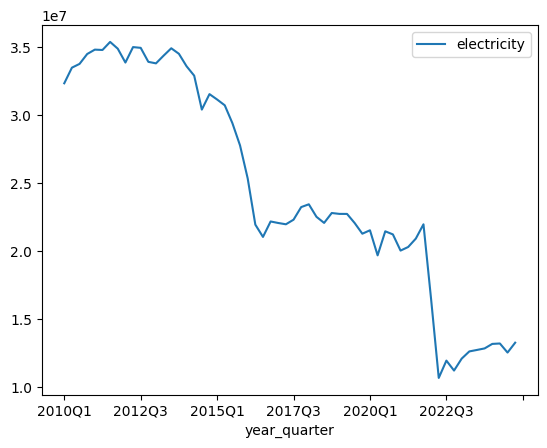

In [27]:
electricity.plot(x="year_quarter", y="electricity", kind="line")

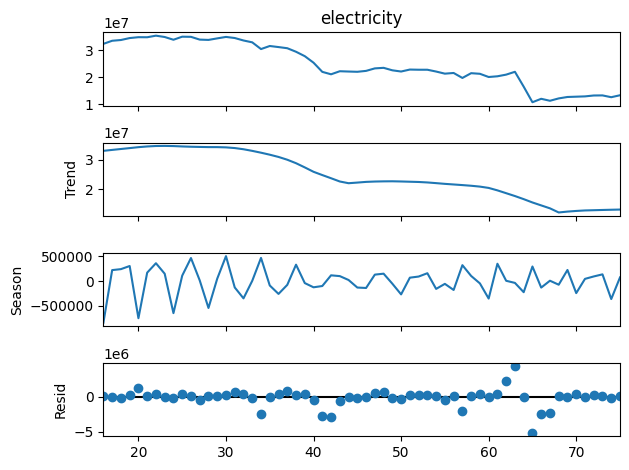

,variable,seasonal_strength
0,electricity,0


In [28]:
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import STL


seasonality_results = []

s = electricity['electricity'].dropna()

stl = STL(s, period=4, robust=True)
res = stl.fit()
fig = res.plot()
plt.show()

stl = STL(s, period=4, robust=True).fit()
seasonal = stl.seasonal
resid = stl.resid

strength = max(0, 1 - np.var(resid) / np.var(seasonal + resid))
seasonality_results.append({
    "variable": 'electricity',
    "seasonal_strength": strength
})

seasonality_df = pd.DataFrame(seasonality_results)
seasonality_df

not seasonal

In [29]:
results_stationarity = []

cols = ["electricity"]

for col in cols:
    s = electricity[col].dropna()

    if len(s) < 10:
        continue

    # ADF
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag="AIC")

    # KPSS
    kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")

    # PP
    pp = PhillipsPerron(s)
    pp_p = pp.pvalue

    results_stationarity.append({
        "variable": col,
        "adf_p": adf_p,
        "pp_p": pp_p,
        "kpss_p": kpss_p
    })

stationarity_df = pd.DataFrame(results_stationarity)
stationarity_df

,variable,adf_p,pp_p,kpss_p
0,electricity,0.852555,0.932614,0.01


In [30]:
electricity["log_electricity"] = np.log(electricity["electricity"])
electricity["dlog_electricity"] = electricity["log_electricity"].diff()

In [31]:
results_stationarity = []

cols = ["electricity", "log_electricity", "dlog_electricity"]

for col in cols:
    s = electricity[col].dropna()

    if len(s) < 10:
        continue

    # ADF
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag="AIC")

    # KPSS
    kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")

    # PP
    pp = PhillipsPerron(s)
    pp_p = pp.pvalue

    results_stationarity.append({
        "variable": col,
        "adf_p": adf_p,
        "pp_p": pp_p,
        "kpss_p": kpss_p
    })

stationarity_df = pd.DataFrame(results_stationarity)
stationarity_df

,variable,adf_p,pp_p,kpss_p
0,electricity,8.525554e-01,9.326135e-01,0.01
1,log_electricity,9.132383e-01,9.353925e-01,0.01
2,dlog_electricity,1.689971e-08,1.917466e-08,0.10


dlog is ststionary

In [32]:
ljungbox_results = []

for col in cols:
    s = electricity[col].dropna()

    if len(s) < 12:
        continue

    lb = acorr_ljungbox(s, lags=[4, 8], return_df=True)
    ljungbox_results.append({
        "variable": col,
        "lb_p_4": lb.loc[4, "lb_pvalue"],
        "lb_p_8": lb.loc[8, "lb_pvalue"]
    })

ljungbox_df = pd.DataFrame(ljungbox_results)
ljungbox_df

,variable,lb_p_4,lb_p_8
0,electricity,2.373197e-42,5.267505e-65
1,log_electricity,6.846168e-40,4.657175e-59
2,dlog_electricity,5.616135e-01,7.737316e-01


Variable: electricity


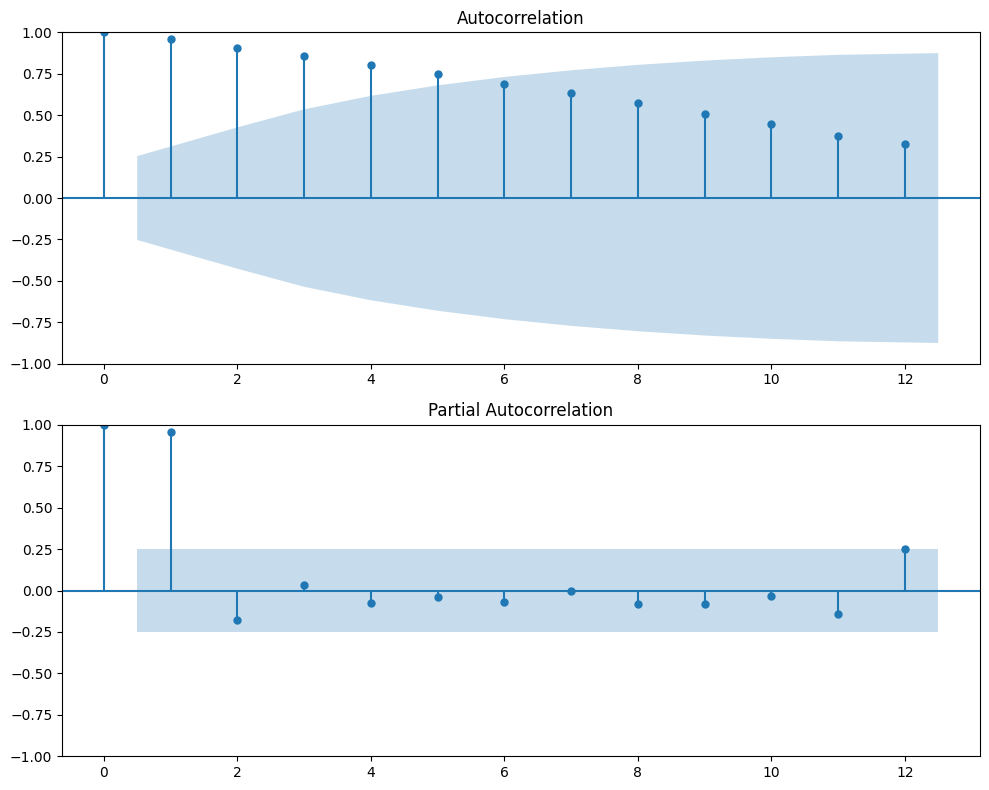

Variable: log_electricity


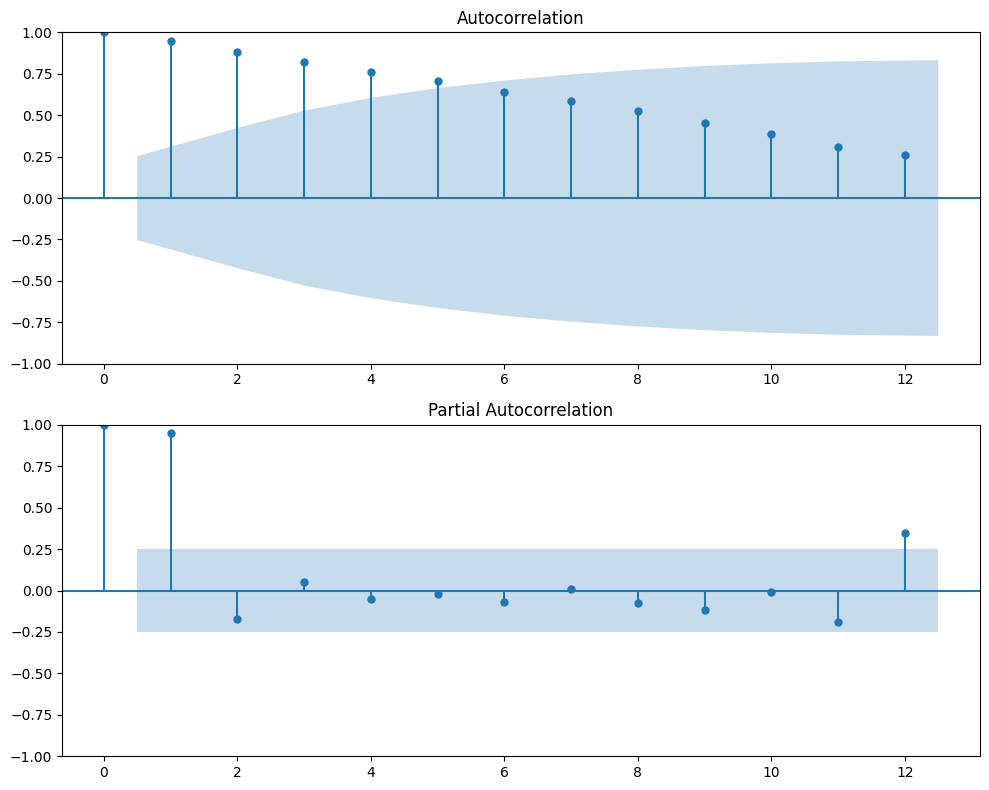

Variable: dlog_electricity


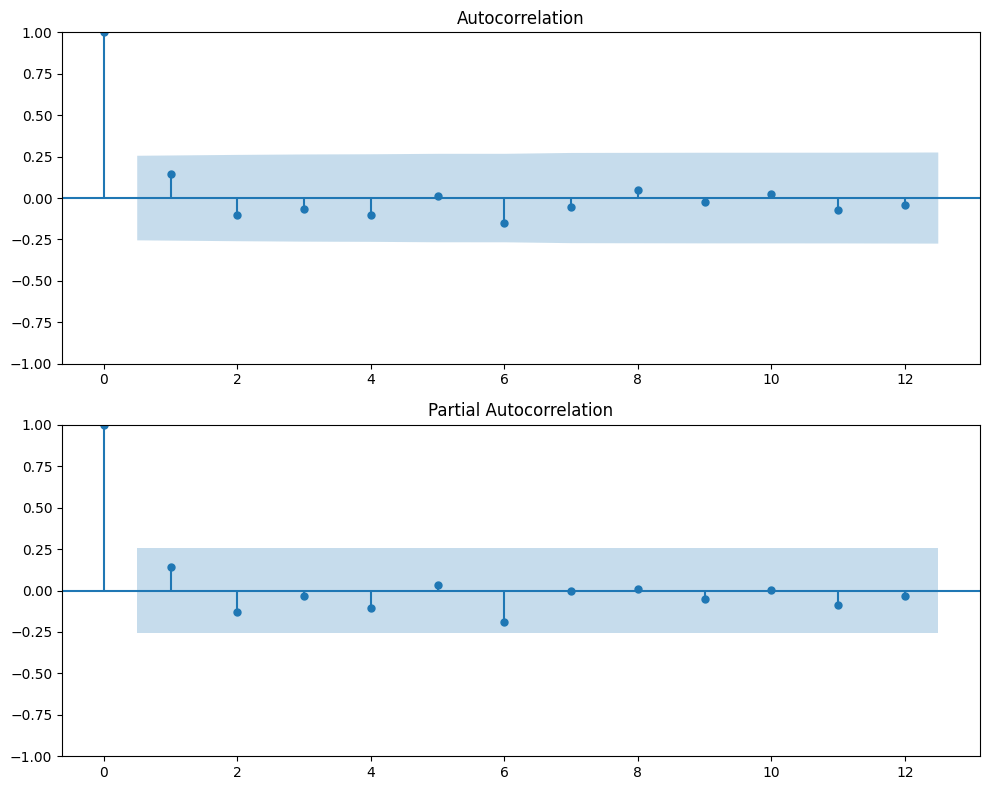

In [33]:
## ACF, PACF

for col in cols:
    s = electricity[col].dropna()

    try:
        print(f"Variable: {col}")
        fig, ax = plt.subplots(2, 1, figsize=(10, 8))
        plot_acf(s, lags=12, ax=ax[0])
        plot_pacf(s, lags=12, ax=ax[1], method="ywm")
        plt.tight_layout()
        plt.show()
    except:
        pass

no autocorrelation for dlog

In [34]:
arch_results = []

for col in cols:
    s = electricity[col].dropna()

    if len(s) < 12:
        continue

    # Often tested on stationary series or residuals
    s_diff = s.diff().dropna()

    if len(s_diff) < 12:
        continue

    lm_stat, lm_p, f_stat, f_p = het_arch(s_diff, nlags=4)

    arch_results.append({
        "variable": col,
        "arch_lm_p": lm_p,
        "arch_f_p": f_p
    })

arch_df = pd.DataFrame(arch_results)
arch_df

,variable,arch_lm_p,arch_f_p
0,electricity,0.000776,0.000237
1,log_electricity,0.031488,0.027603
2,dlog_electricity,0.073785,0.071923


stationary
no significant autocorrelation
no significant ARCH effect at 5%

In [35]:
za_results = []

for col in cols:
    s = electricity[col].dropna()

    if len(s) < 20:
        continue

    try:
        za_stat, za_p, cv, baselag, bp = zivot_andrews(s, maxlag=4)
        za_results.append({
            "variable": col,
            "za_p": za_p,
            "break_index": bp
        })
    except:
        pass

za_df = pd.DataFrame(za_results)
za_df

,variable,za_p,break_index
0,electricity,0.537753,21
1,log_electricity,0.004141,47
2,dlog_electricity,0.000010,50


break at war 2022

In [36]:
electricity.to_csv("data/quarterly_electricity.csv", index=False)